**Importing the required libraries**

In [ ]:
import os
import zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    Flatten, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

**Load FER-2013 Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving FER-2013.zip to FER-2013.zip


**Extract Dataset**

In [ ]:
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("✅ Dataset extracted successfully")

✅ Dataset extracted successfully


**Dataset Structure & Paths**

In [ ]:
train_dir = "FER-2013/train"
test_dir = "FER-2013/test"

img_size = 48
batch_size = 64

**Image Data Generators (Preprocessing)**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1
)

**Load Images from Folders**

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


**Emotion Labels**

In [ ]:
emotion_labels = list(train_generator.class_indices.keys())
print("Emotion classes:", emotion_labels)

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


**Visualize Sample Training Images**

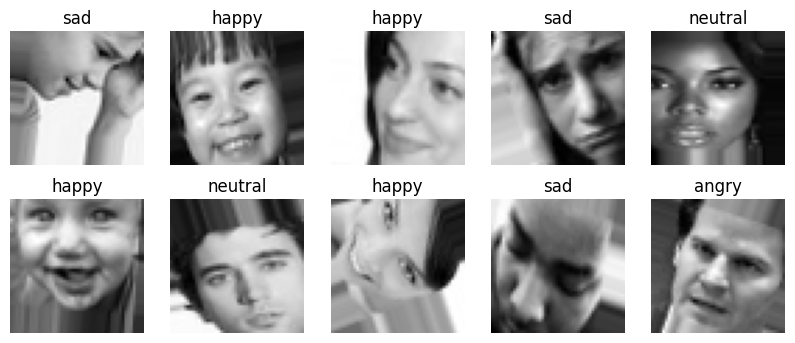

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    img, label = train_generator[0]
    plt.subplot(2,5,i+1)
    plt.imshow(img[i].reshape(48,48), cmap='gray')
    plt.title(emotion_labels[np.argmax(label[i])])
    plt.axis('off')
plt.show()

**Build CNN Model**

In [ ]:
model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(7, activation='softmax'))


**Compile the Model**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

**Train the Model**

In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 736s 2s/step - accuracy: 0.2559 - loss: 1.8033 - val_accuracy: 0.2497 - val_loss: 1.7984 - learning_rate: 3.0000e-04
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 720s 2s/step - accuracy: 0.2977 - loss: 1.7202 - val_accuracy: 0.4136 - val_loss: 1.5205 - learning_rate: 3.0000e-04
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 713s 2s/step - accuracy: 0.3544 - loss: 1.6293 - val_accuracy: 0.4490 - val_loss: 1.4738 - learning_rate: 3.0000e-04
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 725s 2s/step - accuracy: 0.3961 - loss: 1.5500 - val_accuracy: 0.4706 - val_loss: 1.4461 - learning_rate: 3.0000e-04
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 729s 2s/step - accuracy: 0.4313 - loss: 1.4756 - val_accuracy: 0.4943 - val_loss: 1.2993 - learning_rate: 3.0000e-04
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 729s 2s/step - accuracy: 0.4580 - loss: 1.4255 - val_accuracy: 0.5032 - val_loss: 1.3134 - learning_rate: 3.0000e-04
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 721s 2s/step - acc

**Evaluate Model**

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 307ms/step - accuracy: 0.5845 - loss: 1.1012
Test Accuracy: 61.33%


**Emotion Prediction on a Single Image**

In [ ]:
uploaded = files.upload()

Saving close-up-portrait-smiling-laughing-attractive-man-happy-face-human-emotion-expression-african-american-having-fun-joy-145301119.webp to close-up-portrait-smiling-laughing-attractive-man-happy-face-human-emotion-expression-african-american-having-fun-joy-145301119 (3).webp


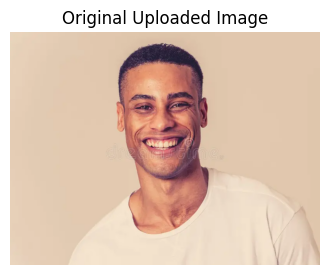

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


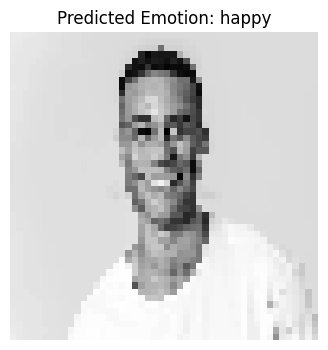

In [ ]:
img_path = list(uploaded.keys())[0]

# 🔹 Read original image (color)
original_img = cv2.imread(img_path)
original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# 🔹 Display original image
plt.figure(figsize=(4,4))
plt.imshow(original_img_rgb)
plt.title("Original Uploaded Image")
plt.axis('off')
plt.show()

# 🔹 Preprocess image for model
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (48,48))
img = img / 255.0
img = img.reshape(1,48,48,1)

# 🔹 Predict emotion
prediction = model.predict(img)
predicted_emotion = emotion_labels[np.argmax(prediction)]

# 🔹 Display processed image with prediction
plt.figure(figsize=(4,4))
plt.imshow(img.reshape(48,48), cmap='gray')
plt.title(f"Predicted Emotion: {predicted_emotion}")
plt.axis('off')
plt.show()

In [ ]:
model.save("emotion_recognition_cnn.h5")